# Analyse Exploratoire et Clustering des données de Mobilité (Oslo Bysykkel)

**Objectif du Notebook :**
Ce document présente le pipeline complet de traitement des données de vélos en libre-service de la ville d'Oslo. L'objectif est d'extraire des comportements d'utilisation récurrents via un algorithme d'apprentissage non supervisé (K-Means) afin d'alimenter un tableau de bord d'aide à la décision.

**Étapes :**
1. Nettoyage et ingénierie des caractéristiques (Feature Engineering).
2. Analyse Exploratoire des Données (EDA) et visualisations.
3. Choix et paramétrage du modèle de clustering.
4. Profilage métier et export de la base de données.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Chargement des données
df = pd.read_csv('../data/osloTest.csv')
df['started_at'] = pd.to_datetime(df['started_at'], format="mixed")
df['ended_at'] = pd.to_datetime(df['ended_at'], format='mixed')

print(f"Données brutes chargées : {df.shape[0]} trajets.")

Données brutes chargées : 1188 trajets.


## 1. Feature Engineering (Ingénierie des caractéristiques)

Pour que l'algorithme puisse identifier des "profils", nous devons transformer les horodatages bruts en variables explicatives quantitatives et binaires.
Nous ciblons deux axes principaux :
* **Axe Temporel :** Extraction de l'heure, de la durée, et création de drapeaux binaires (heures de pointe, nuit, week-end).
* **Axe Spatial :** Catégorisation des stations de départ en fonction de la géographie urbaine d'Oslo (Quartiers d'affaires, zones touristiques, quartiers festifs).

In [3]:
# Variables temporelles
df['duration_min'] = df['duration'] / 60
df['hour'] = df['started_at'].dt.hour
df['day_of_week'] = df['started_at'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Filtrage des valeurs aberrantes (erreurs de borne ou vols)
df = df[(df['duration_min'] >= 1) & (df['duration_min'] <= 120)].dropna()

# Listes des Points d'Intérêt (POI)
business_stations = ["Barcode", "Aker Brygge", "Nationaltheatret", "Tollbugata", "Skøyen"]
nightlife_stations = ["Olaf Ryes plass", "Schous plass", "Youngstorget", "Storgata", "Birkelunden"]
tourist_stations = ["Vigelandsparken", "Operahuset", "Munch-museet", "Karl Johan", "Rådhusplassen"]

# Variables métiers binaires
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 22 or x <= 5 else 0)
df['is_rush_hour'] = df.apply(lambda r: 1 if (r['hour'] in [7,8,9,16,17,18]) and (r['is_weekend'] == 0) else 0, axis=1)

df['is_business_poi'] = df['start_station_name'].apply(lambda x: 1 if any(s in str(x) for s in business_stations) else 0)
df['is_nightlife_poi'] = df['start_station_name'].apply(lambda x: 1 if any(s in str(x) for s in nightlife_stations) else 0)
df['is_tourist_poi'] = df['start_station_name'].apply(lambda x: 1 if any(s in str(x) for s in tourist_stations) else 0)

## 2. Analyse Exploratoire (EDA)

Avant de modéliser, nous vérifions la distribution de nos données. La boîte à moustaches (Boxplot) permet d'observer la dispersion des durées de trajet et d'identifier les différences de comportement entre la semaine et le week-end.

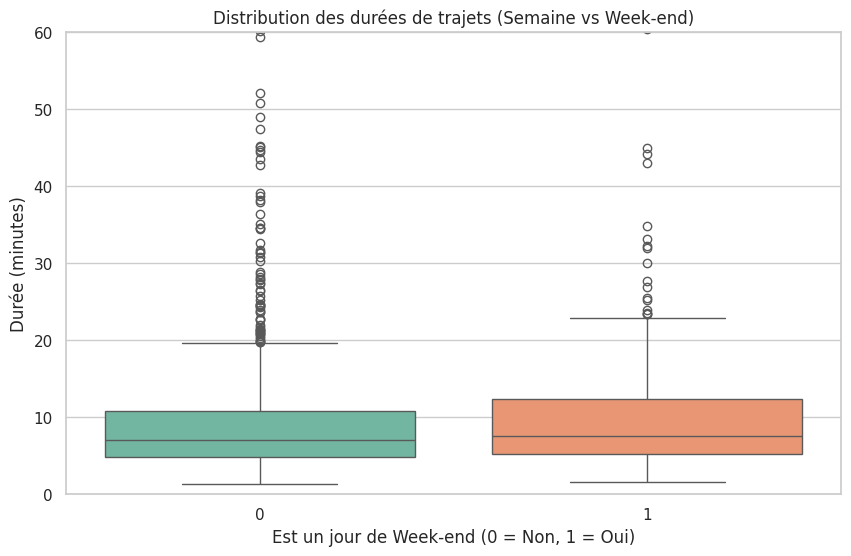

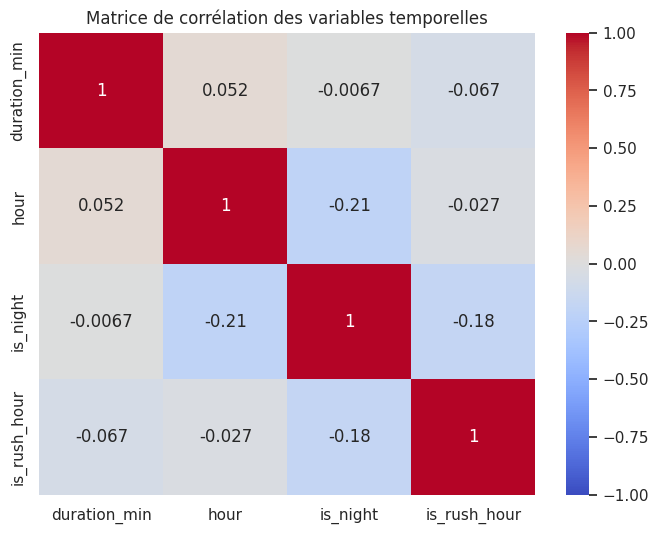

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_weekend', y='duration_min', data=df, palette="Set2")
plt.title("Distribution des durées de trajets (Semaine vs Week-end)")
plt.xlabel("Est un jour de Week-end (0 = Non, 1 = Oui)")
plt.ylabel("Durée (minutes)")
plt.ylim(0, 60) # Restriction visuelle pour ignorer les valeurs extrêmes
plt.show()

# Matrice de corrélation
plt.figure(figsize=(8, 6))
correlation_cols = ['duration_min', 'hour', 'is_night', 'is_rush_hour']
sns.heatmap(df[correlation_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables temporelles")
plt.show()

## 3. Configuration de l'Algorithme (K-Means vs DBSCAN)

**Pourquoi le K-Means ?**
Bien que DBSCAN soit efficace pour isoler le "bruit" spatial, le K-Means répond mieux à notre besoin métier : forcer la segmentation de la base de données en groupes exploitables pour l'interface utilisateur.

**Choix de la distance et standardisation :**
Le K-Means calcule l'appartenance aux clusters en utilisant la distance euclidienne : $d(p, q) = \sqrt{\sum_{i=1}^{n} (q_i - p_i)^2}$.
Puisque nos variables n'ont pas la même échelle (des heures de 0 à 23, des minutes de 1 à 120, et des booléens 0/1), il est impératif d'utiliser un `StandardScaler` pour centrer et réduire les données. Sans cela, la variable "durée" écraserait mathématiquement les variables binaires.

**Méthode du coude (Elbow Method) pour choisir K :**
Pour valider le nombre optimal de clusters ($k$), nous calculons l'inertie intra-classe. Un point d'inflexion (coude) autour de $k=4$ confirme la pertinence statistique de diviser nos usagers en 4 grands profils.

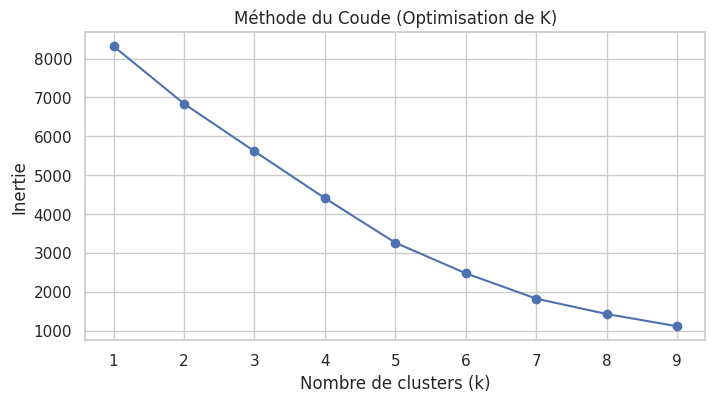

Clustering K-Means terminé avec k=4.


In [5]:
features = ['duration_min', 'hour', 'is_night', 'is_rush_hour', 'is_business_poi', 'is_nightlife_poi', 'is_tourist_poi']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# Visualisation de la méthode du coude
inertia = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o')
plt.title("Méthode du Coude (Optimisation de K)")
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.show()

# Application du modèle final
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering K-Means terminé avec k=4.")

## 4. Profilage Métier et Interprétation des Centroïdes

L'algorithme a regroupé mathématiquement les trajets. Nous devons maintenant donner un sens métier à ces groupes (clusters) en observant les moyennes de leurs caractéristiques (centroïdes). L'attribution est réalisée par un système de classement des valeurs dominantes.

In [6]:
# Identification dynamique des profils basée sur les caractéristiques
cluster_ids = sorted(df['cluster'].unique())
durations = df.groupby('cluster')['duration_min'].mean()

id_touriste = durations.idxmax()
id_nuit = df.groupby('cluster')['is_night'].mean().idxmax()
id_tafeur = df.groupby('cluster')['is_rush_hour'].mean().idxmax()

tous_les_ids = set(cluster_ids)
deja_pris = {id_touriste, id_nuit, id_tafeur}
id_standard = list(tous_les_ids - deja_pris)[0]

noms_profils = {
    id_nuit: "Noctambules",
    id_tafeur: "Vélotafeurs",
    id_touriste: "Touristes / Loisirs",
    id_standard: "Locaux / Déplacements standards"
}

df['Profil_Metier'] = df['cluster'].map(noms_profils)

# Validation des résultats
print("--- RÉPARTITION FINALE ---")
print(df['Profil_Metier'].value_counts())

print("\n--- ANALYSE DES CENTROÏDES ---")
print(df.groupby('Profil_Metier')[['duration_min', 'hour', 'is_rush_hour', 'is_night']].mean())

# Sauvegarde pour exploitation applicative
conn = sqlite3.connect('../data/oslo_v2.db')
df.to_sql('trips_clustered', conn, if_exists='replace', index=False)
conn.close()

print("\nExport reussi : Base de donnees sqlite mise a jour pour le tableau de bord.")

--- RÉPARTITION FINALE ---
Profil_Metier
Locaux / Déplacements standards    702
Vélotafeurs                        405
Noctambules                         69
Touristes / Loisirs                 12
Name: count, dtype: int64

--- ANALYSE DES CENTROÏDES ---
                                 duration_min       hour  is_rush_hour  \
Profil_Metier                                                            
Locaux / Déplacements standards     10.039459  12.847578          0.00   
Noctambules                          9.365942   8.594203          0.00   
Touristes / Loisirs                 12.376389  14.083333          0.25   
Vélotafeurs                          8.785185  12.200000          1.00   

                                 is_night  
Profil_Metier                              
Locaux / Déplacements standards       0.0  
Noctambules                           1.0  
Touristes / Loisirs                   0.0  
Vélotafeurs                           0.0  

Export reussi : Base de donnees sql